# Comparo SOH para los distintos dataset

In [1]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft
import utils_deriv as utl

✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [2]:
import numpy as np
import pandas as pd
from importlib import reload
from datetime import datetime, timedelta, timezone

## 45°C

In [3]:
# --- carga de datos ---
nombre_dataset = 'NMC-45C-parte1-cada3'
path_json = f"../tmp/{nombre_dataset}.json"
dict_ciclos_sep_45 = pr.cargar_json(path_json)
indices_ciclos_45 = list(dict_ciclos_sep_45.keys())

for ciclo, datos in dict_ciclos_sep_45.items():
    for modo in ['Ch', 'Dis']:
        df = datos[modo]
        df_ordenado = df.sort_values('Time').reset_index(drop=True)
        dict_ciclos_sep_45[ciclo][modo] = df_ordenado

Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 164


In [4]:
# --- Selección de ciclos ---
ciclos_sel_todos_45 = pr.seleccionar_ciclos(
    dict_ciclos_sep_45,
    #rango=(21, 900),
    #excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 163 ciclos seleccionados
   → [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 213, 216, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 414, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447, 450, 453, 456, 459, 462, 465, 468, 471, 474, 477, 480, 483, 486]


La capacidad máxima es 2868.585 mAh y se alcanza en el ciclo 6.


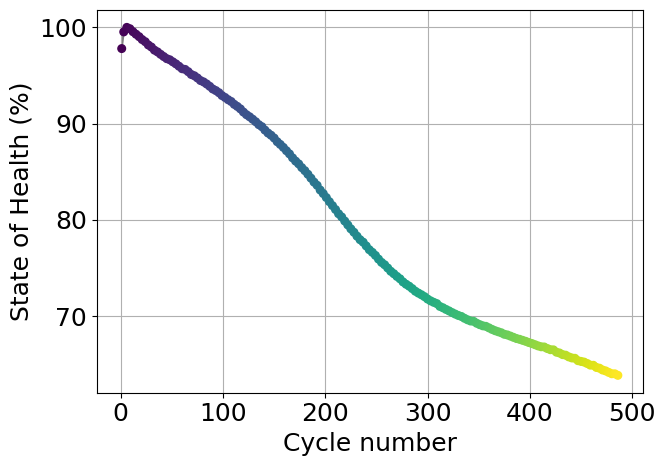

(     ciclo         qmax         soh
 0        1  2805.425190   97.798220
 1        3  2855.176140   99.532558
 2        6  2868.585121  100.000000
 3        9  2864.602586   99.861167
 4       12  2855.768434   99.553205
 ..     ...          ...         ...
 158    474  1844.395763   64.296358
 159    477  1840.024658   64.143980
 160    480  1835.883077   63.999603
 161    483  1835.688778   63.992829
 162    486  1831.170286   63.835313
 
 [163 rows x 3 columns],
 np.float64(2868.5851208),
 6)

In [5]:
pl.plot_soh(dict_ciclos_sep_45, ciclos_sel_todos_45, nombre_dataset, Path('../tmp'))

In [6]:
reload(pl)

<module 'plotting' from '/home/mariajose/proc-icdv/src/plotting.py'>

[165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 213, 216, 219, 222]


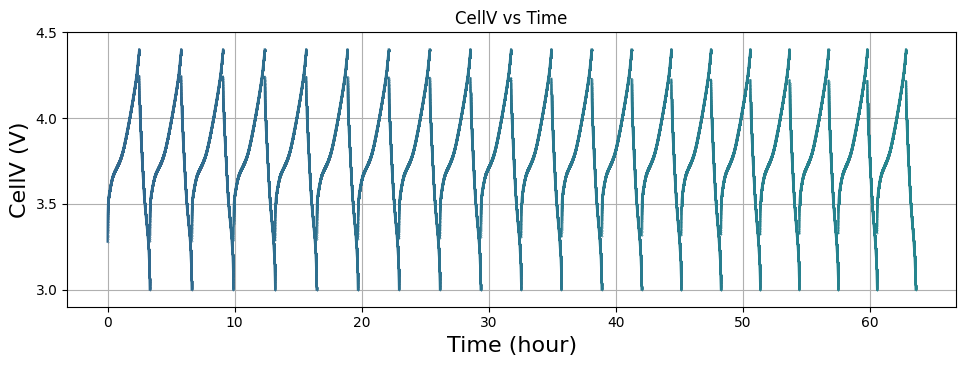

In [10]:
pl.plot_n_cycles_tvsV_continuo(ciclos_sel_todos_45[55:75], dict_ciclos_sep_45, nombre_dataset)

[1, 18, 36, 54, 72, 90, 108, 126, 144, 162, 180, 198, 216, 234, 252, 270, 288, 306, 324, 342, 360, 378, 396, 414, 432, 450, 468, 486]


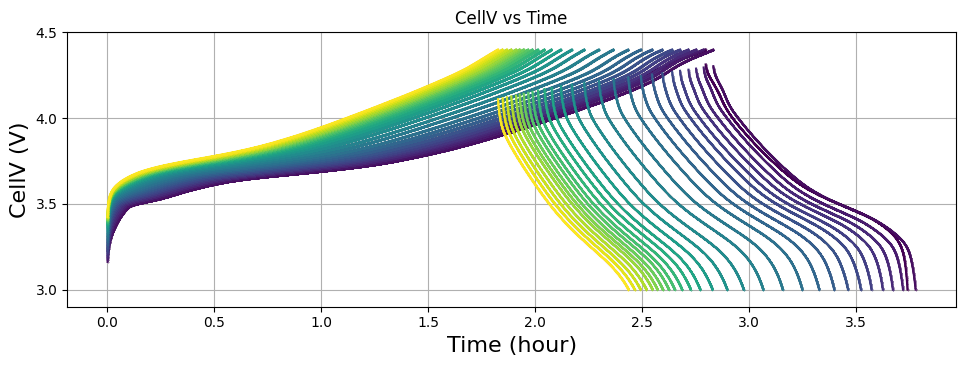

In [7]:
ciclos_sel_grafico_45 = [ciclos_sel_todos_45[i] for i in range(len(ciclos_sel_todos_45)) if i % 6 == 0]
pl.plot_n_cycles_tvsV(ciclos_sel_grafico_45, dict_ciclos_sep_45, nombre_dataset)

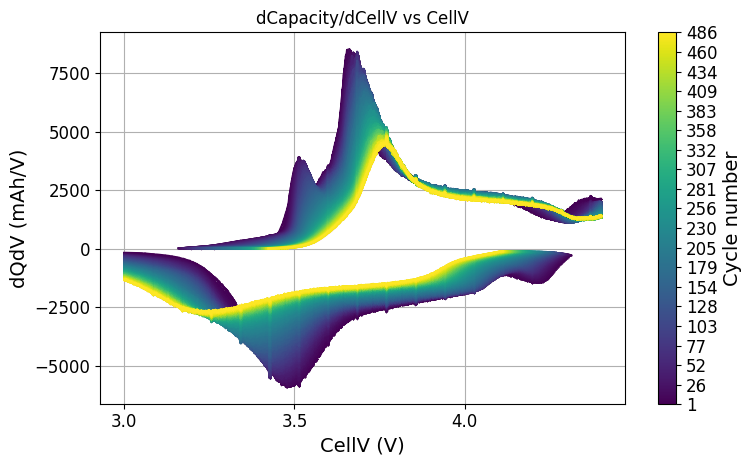

In [16]:
pl.plot_n_cycles_dqdv(ciclos_sel_todos_45, dict_ciclos_sep_45)

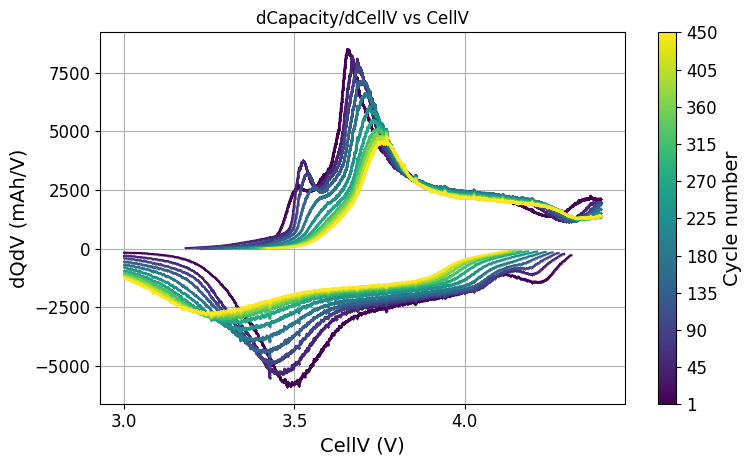

In [17]:
ciclos_sel_grafico_45 = [ciclos_sel_todos_45[i] for i in range(len(ciclos_sel_todos_45)) if i % 15 == 0]
pl.plot_n_cycles_dqdv(ciclos_sel_grafico_45, dict_ciclos_sep_45)

## 20°C

In [18]:
# --- carga de datos ---
nombre_dataset = 'NMC-20'
path_json = f"../tmp/{nombre_dataset}.json"
dict_ciclos_sep_20 = pr.cargar_json(path_json)
indices_ciclos_20 = list(dict_ciclos_sep_20.keys())

Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 301


In [26]:
# --- Selección de ciclos ---
ciclos_sel_todos_20 = pr.seleccionar_ciclos(
    dict_ciclos_sep_20,
    rango=(21, 900),
    excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 288 ciclos seleccionados
   → [21, 24, 27, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 195, 198, 201, 204, 207, 210, 213, 216, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 414, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447, 450, 453, 456, 459, 462, 465, 468, 471, 474, 477, 480, 483, 486, 489, 492, 495, 498, 501, 504, 507, 510, 513, 516, 519, 522, 525, 528, 531, 534, 537, 540, 543, 546, 549, 552, 555, 558, 561, 564, 567, 570, 573, 576, 579, 582, 585, 588, 591, 594, 597, 600, 603, 606, 609, 612, 615, 618, 621, 624, 627

La capacidad máxima es 2581.198 mAh y se alcanza en el ciclo 21.


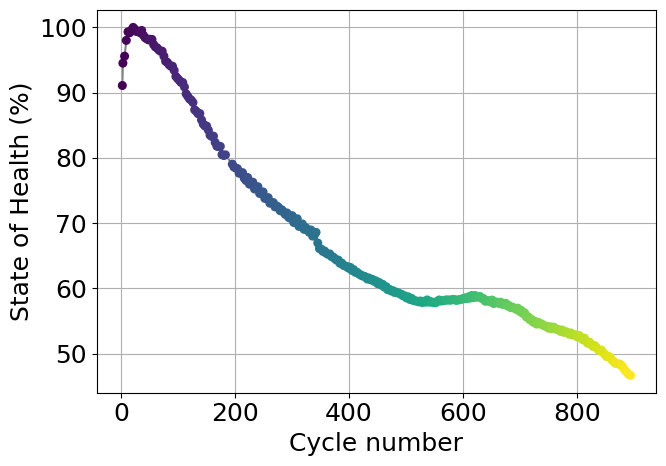

(     ciclo         qmax        soh
 0        2  2351.282208  91.092675
 1        3  2439.757839  94.520371
 2        6  2467.317531  95.588081
 3        9  2529.807227  98.009038
 4       12  2563.637171  99.319667
 ..     ...          ...        ...
 290    882  1231.624382  47.715225
 291    885  1222.318882  47.354714
 292    888  1214.951805  47.069301
 293    891  1207.404985  46.776924
 294    894  1204.392472  46.660214
 
 [295 rows x 3 columns],
 np.float64(2581.1979025),
 21)

In [23]:
pl.plot_soh(dict_ciclos_sep_20, ciclos_sel_todos_20, nombre_dataset, Path('../tmp'))

[2, 18, 39, 57, 75, 93, 111, 129, 147, 165, 183, 210, 228, 246, 264, 282, 300, 318, 336, 354, 372, 390, 408, 426, 444, 462, 480, 498, 516, 534, 552, 570, 588, 606, 624, 642, 660, 678, 696, 714, 732, 750, 768, 786, 804, 822, 840, 858, 876, 894]


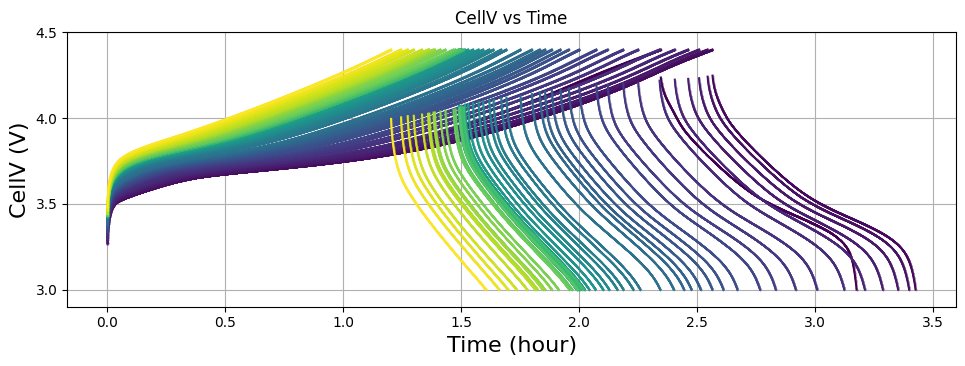

In [24]:
ciclos_sel_grafico_20 = [ciclos_sel_todos_20[i] for i in range(len(ciclos_sel_todos_20)) if i % 6 == 0]
pl.plot_n_cycles_tvsV(ciclos_sel_grafico_20, dict_ciclos_sep_20, nombre_dataset)

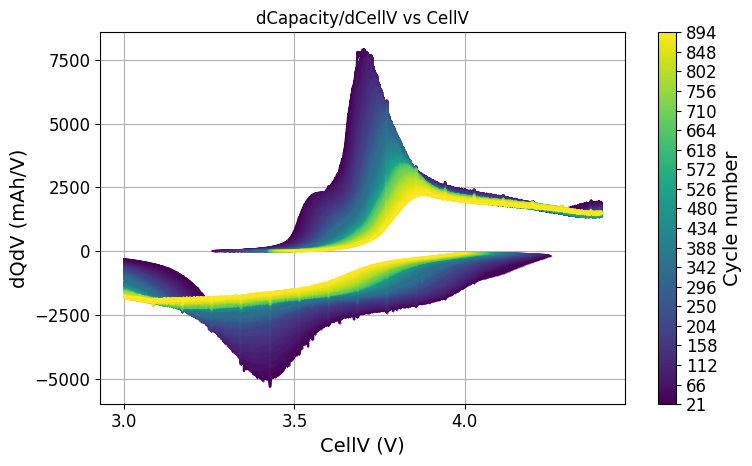

In [27]:
pl.plot_n_cycles_dqdv(ciclos_sel_todos_20, dict_ciclos_sep_20)

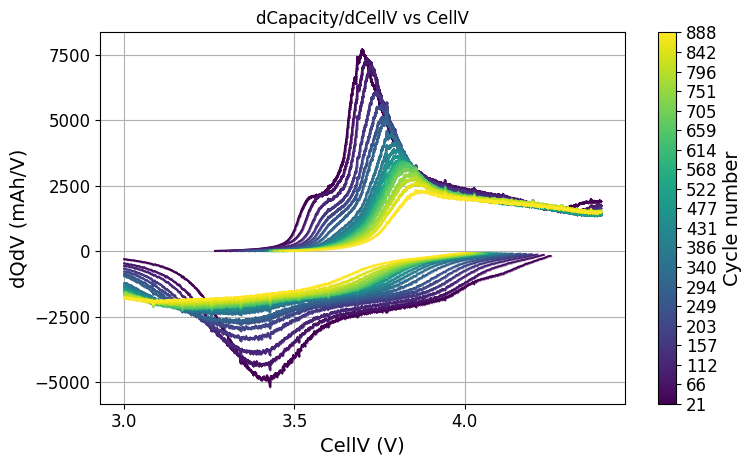

In [28]:
ciclos_sel_grafico_20 = [ciclos_sel_todos_20[i] for i in range(len(ciclos_sel_todos_20)) if i % 15 == 0]
pl.plot_n_cycles_dqdv(ciclos_sel_grafico_20, dict_ciclos_sep_20)

## 10°C

In [29]:
# --- carga de datos ---
nombre_dataset = 'NMC-10-cada3'
path_json = f"../tmp/{nombre_dataset}.json"
dict_ciclos_sep_10 = pr.cargar_json(path_json)
indices_ciclos_10 = list(dict_ciclos_sep_10.keys())


Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 67


In [30]:
# --- Selección de ciclos ---
ciclos_sel_todos_10 = pr.seleccionar_ciclos(
    dict_ciclos_sep_10,
    #rango=(21, 900),
    #excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 66 ciclos seleccionados
   → [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]


La capacidad máxima es 2290.846 mAh y se alcanza en el ciclo 6.


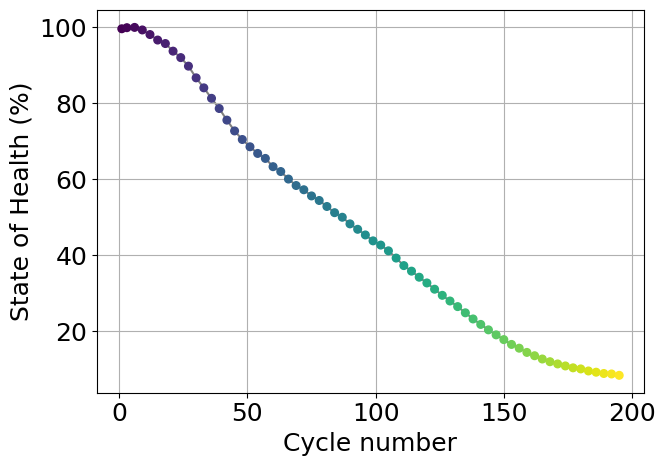

(    ciclo         qmax         soh
 0       1  2282.593107   99.639751
 1       3  2289.128027   99.925013
 2       6  2290.845866  100.000000
 3       9  2275.454014   99.328115
 4      12  2247.734647   98.118109
 ..    ...          ...         ...
 61    183   220.171146    9.610910
 62    186   212.708445    9.285149
 63    189   204.962332    8.947015
 64    192   202.100881    8.822107
 65    195   193.875590    8.463057
 
 [66 rows x 3 columns],
 np.float64(2290.8458664),
 6)

In [31]:
pl.plot_soh(dict_ciclos_sep_10, ciclos_sel_todos_10, nombre_dataset, Path('../tmp'))

[1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]


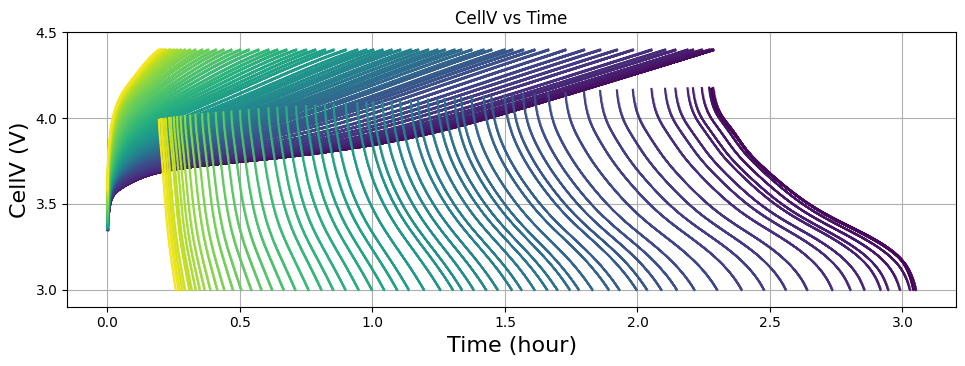

In [33]:
#ciclos_sel_grafico_10 = [ciclos_sel_todos_10[i] for i in range(len(ciclos_sel_todos_10)) if i % 6 == 0]
pl.plot_n_cycles_tvsV(ciclos_sel_todos_10, dict_ciclos_sep_10, nombre_dataset)

In [ ]:
pl.plot_n_cycles_dqdv(ciclos_sel_todos_10, dict_ciclos_sep_10)